      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

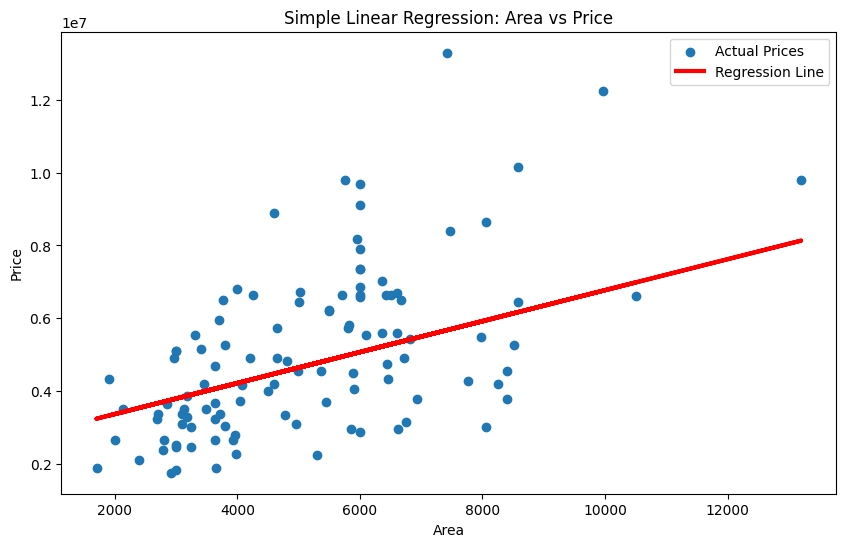

Slope: 425.72984193878284
Intercept: 2512254.2639593435

--- Multiple Linear Regression (Area, Bedrooms, Bathrooms vs Price) ---
MAE: 1265275.6699454375
MSE: 2750040479309.0522
R²: 0.4559299118872445
     Feature   Coefficient
0       area  3.454666e+02
1   bedrooms  3.601977e+05
2  bathrooms  1.422320e+06


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Load dataset
df = pd.read_csv("/content/Housing.csv")

# Display data
print(df.head())
print(df.info())
print(df.describe())
df = df.dropna()

# Simple Linear Regression (corrected to use existing columns)
X_slr = df[['area']]
y_slr = df['price']
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)
slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)
y_pred_slr = slr_model.predict(X_test_slr)

mae_slr = mean_absolute_error(y_test_slr, y_pred_slr)
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test_slr, y_pred_slr)

print("\n--- Simple Linear Regression (Area vs Price) ---")
print("MAE:", mae_slr)
print("MSE:", mse_slr)
print("RMSE:", rmse_slr)
print("R² Score:", r2_slr)

plt.figure(figsize=(10, 6))
plt.scatter(X_test_slr, y_test_slr, label='Actual Prices')
plt.plot(X_test_slr, y_pred_slr, color='red', linewidth=3, label='Regression Line')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Area vs Price")
plt.legend()
plt.show()
print("Slope:", slr_model.coef_[0])
print("Intercept:", slr_model.intercept_)

# Multiple Linear Regression (already using existing columns)
X_mlr = df[['area', 'bedrooms', 'bathrooms']]
y_mlr = df['price']
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42
)
mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)
y_pred_mlr = mlr_model.predict(X_test_mlr)

print("\n--- Multiple Linear Regression (Area, Bedrooms, Bathrooms vs Price) ---")
print("MAE:", mean_absolute_error(y_test_mlr, y_pred_mlr))
print("MSE:", mean_squared_error(y_test_mlr, y_pred_mlr))
print("R²:", r2_score(y_test_mlr, y_pred_mlr))
coeff_df = pd.DataFrame({
    "Feature": X_mlr.columns,
    "Coefficient": mlr_model.coef_
})

print(coeff_df)